##### ***VGG***
###### 虽然AlexNet取得了成功，但它并没有提供一个通用的模版来指导后人设计新的神经网络，而神经网络架构的设计从开始的单个神经元，发展到层，而后又转向块，重复层的设计模式，而VGG则是在AlexNet的基础上，使用块的想法，将重复的层抽象成一个块，从而减少了参数的数量，同时也提高了模型的可维护性。
###### 经典的卷积神经网络的基本组成部分是下面的序列：1. 卷积层2. 激活函数3. 池化层
###### 而一个VGG块与之类似，由一系列卷积层组成，后面再加上用于空间下采样的最大池化层。在论文中，作者使用了卷积核为3x3的卷积层，填充为1，步幅为1，输出通道数为64，然后使用最大池化层(2x2,stride=2)。因为他们发现使用窄且深的卷积层效果会更好。
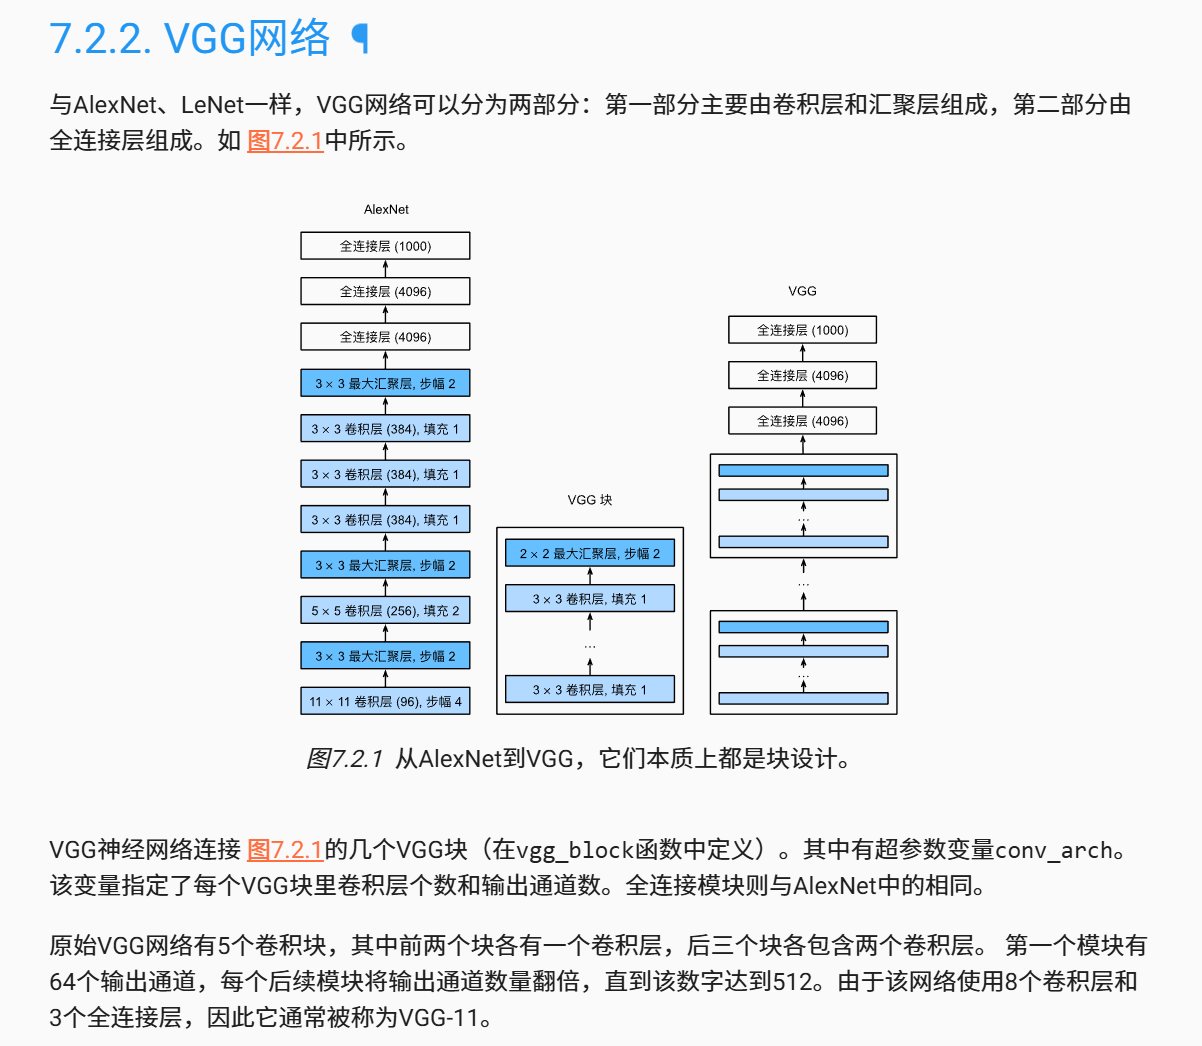

In [7]:
import torch
from torch import nn
from d2l import torch as d2l

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

In [8]:
# 八个卷积层和三个全连接层，被称为VGG-11
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))


In [9]:
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels
    
    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        nn.Linear(out_channels*7 *7, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, 10)
    )         
net = vgg(conv_arch)

In [11]:
X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__, 'output shape:\t', X.shape)


Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


In [ ]:
# 原版的VGG太大，我们可以将其缩放
ratio = 4 # 缩放系数
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch] # 每个卷积层的输出通道数缩放
net = vgg(small_conv_arch)

KeyboardInterrupt: 

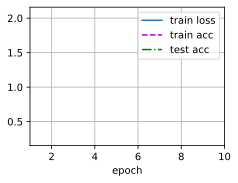

In [13]:
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize = 224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())


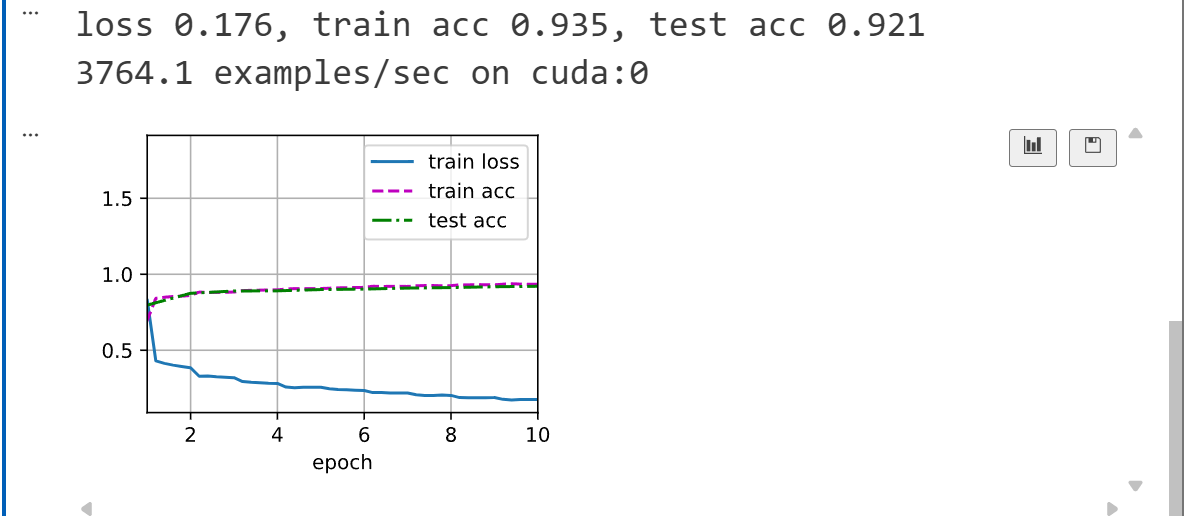